# 03 시계열 분석

## 이 단계 실행 준비



In [1]:
from pathlib import Path
import sys

sys.dont_write_bytecode = True
working_dir = Path.cwd().resolve()
root = (
    working_dir if (working_dir / "src" / "paths.py").is_file() else working_dir.parent
)
sys.path.insert(0, str(root / "src"))
from IPython.display import display, Image

## 주기별 센서 신호 통계

표본 평균·모표준편차(자유도)·95%−5% 분위 폭을 계산한다. A16 센서 특징을 전체 주기 초로 나누어 7구간의 주기별 센서 신호 평균을 얻는다. 

In [2]:
from preprocess import load_cycles, load_splits, load_episodes
from data_checks import read_sensor
from time_series import (
    cycle_signal_statistics,
    summarize_time_series,
    save_signal_statistics,
    output_paths,
)

f = load_cycles()
splits = load_splits(f)
episodes = load_episodes()
raw = read_sensor()
feat = cycle_signal_statistics(raw, f, set(f.loc[splits.train, "cycle_id"]))
statistics = feat[["cycle_id"] + [c for c in feat.columns if c not in f.columns]]
save_signal_statistics(statistics)
time_result = summarize_time_series(feat)
display(time_result["monthly"].head(16))

,month,category,feature,n_cycles,median,q25,q75,mean
0,2020-03,background,cycle_minutes,1482,23.116667,18.350000,28.250000,23.648684
1,2020-03,background,pressure_cycle_mean,1482,9.062332,8.999267,9.132933,9.074607
2,2020-03,background,current_cycle_mean,1482,1.746823,1.389764,2.238915,2.041968
3,2020-03,background,pressure_cycle_sd,1482,0.578075,0.564627,0.593782,0.582462
4,2020-03,background,current_cycle_sd,1482,2.124485,1.959012,2.202254,2.023579
5,2020-03,background,pressure_cycle_p95_p05,1482,1.798000,1.761000,1.836300,1.802763
6,2020-03,background,current_cycle_p95_p05,1482,5.905000,5.798094,5.960000,5.515360
7,2020-03,background,run_fraction,1482,0.100865,0.075990,0.140986,0.125578
8,2020-04,background,cycle_minutes,849,26.933333,24.633333,31.533333,27.306144
9,2020-04,background,pressure_cycle_mean,849,9.026858,8.990078,9.059205,9.036999


## 하루별 값의 분포와 최근 24시간 변화

그래프의 띠는 관측값 가운데 중간 50%가 모여 있는 범위를 보여준다. 최근 24시간 통계는 해당 시간 안에 관측값이 3개 이상 있을 때 계산하며, 빠진 값은 채우지 않는다. 이전 값과의 차이는 센서 기록이 30초를 초과해 끊기지 않은 같은 구간 안에서만 계산한다.

In [3]:
display(time_result["daily"].head(12))
display(time_result["rolling"].head())
from plot_time_series import plot_daily_patterns

plot_daily_patterns(time_result["daily"], episodes, f)

,date,feature,n_cycles,median,q25,q75,mean,sd_across_cycles
0,2020-03-01,cycle_minutes,60,19.816667,19.612500,19.983333,19.736944,0.306429
1,2020-03-01,pressure_cycle_mean,60,9.137842,9.122926,9.147267,9.136593,0.015739
2,2020-03-01,current_cycle_mean,60,2.045010,2.029501,2.063616,2.048060,0.033692
3,2020-03-01,pressure_cycle_sd,60,0.581421,0.579365,0.584180,0.582407,0.005048
4,2020-03-01,current_cycle_sd,60,2.226951,2.220815,2.234395,2.227362,0.012531
5,2020-03-01,pressure_cycle_p95_p05,60,1.807200,1.798150,1.821875,1.810917,0.017593
6,2020-03-01,current_cycle_p95_p05,60,5.899375,5.879844,5.929750,5.902571,0.038851
7,2020-03-01,run_fraction,60,0.116064,0.111932,0.117797,0.115873,0.005117
8,2020-03-02,cycle_minutes,81,15.850000,11.233333,19.483333,15.314403,4.432025
9,2020-03-02,pressure_cycle_mean,81,9.127564,9.059740,9.156215,9.117531,0.104486


,cycle_end,cycle_id,raw_block,cycle_minutes,pressure_cycle_mean,current_cycle_mean,cycle_minutes_past24h_mean,cycle_minutes_past24h_sd,cycle_minutes_change,pressure_cycle_mean_past24h_mean,pressure_cycle_mean_past24h_sd,pressure_cycle_mean_change,current_cycle_mean_past24h_mean,current_cycle_mean_past24h_sd,current_cycle_mean_change
0,2020-03-01 04:32:22,cycle_0214925,37,19.816667,9.125367,2.052083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-01 04:52:21,cycle_0215045,37,19.983333,9.136727,2.055413,NaN,NaN,0.166667,NaN,NaN,0.011361,NaN,NaN,0.003330
2,2020-03-01 05:12:11,cycle_0215166,37,19.833333,9.117533,2.010104,19.877778,0.074949,-0.150000,9.126542,0.007880,-0.019194,2.039200,0.020619,-0.045309
3,2020-03-01 05:31:40,cycle_0215286,37,19.483333,9.126458,2.033814,19.779167,0.182717,-0.350000,9.126521,0.006824,0.008924,2.037854,0.018008,0.023709
4,2020-03-01 05:51:30,cycle_0215404,37,19.833333,9.123017,1.994458,19.790000,0.164857,0.350000,9.125820,0.006263,-0.003441,2.029175,0.023680,-0.039355


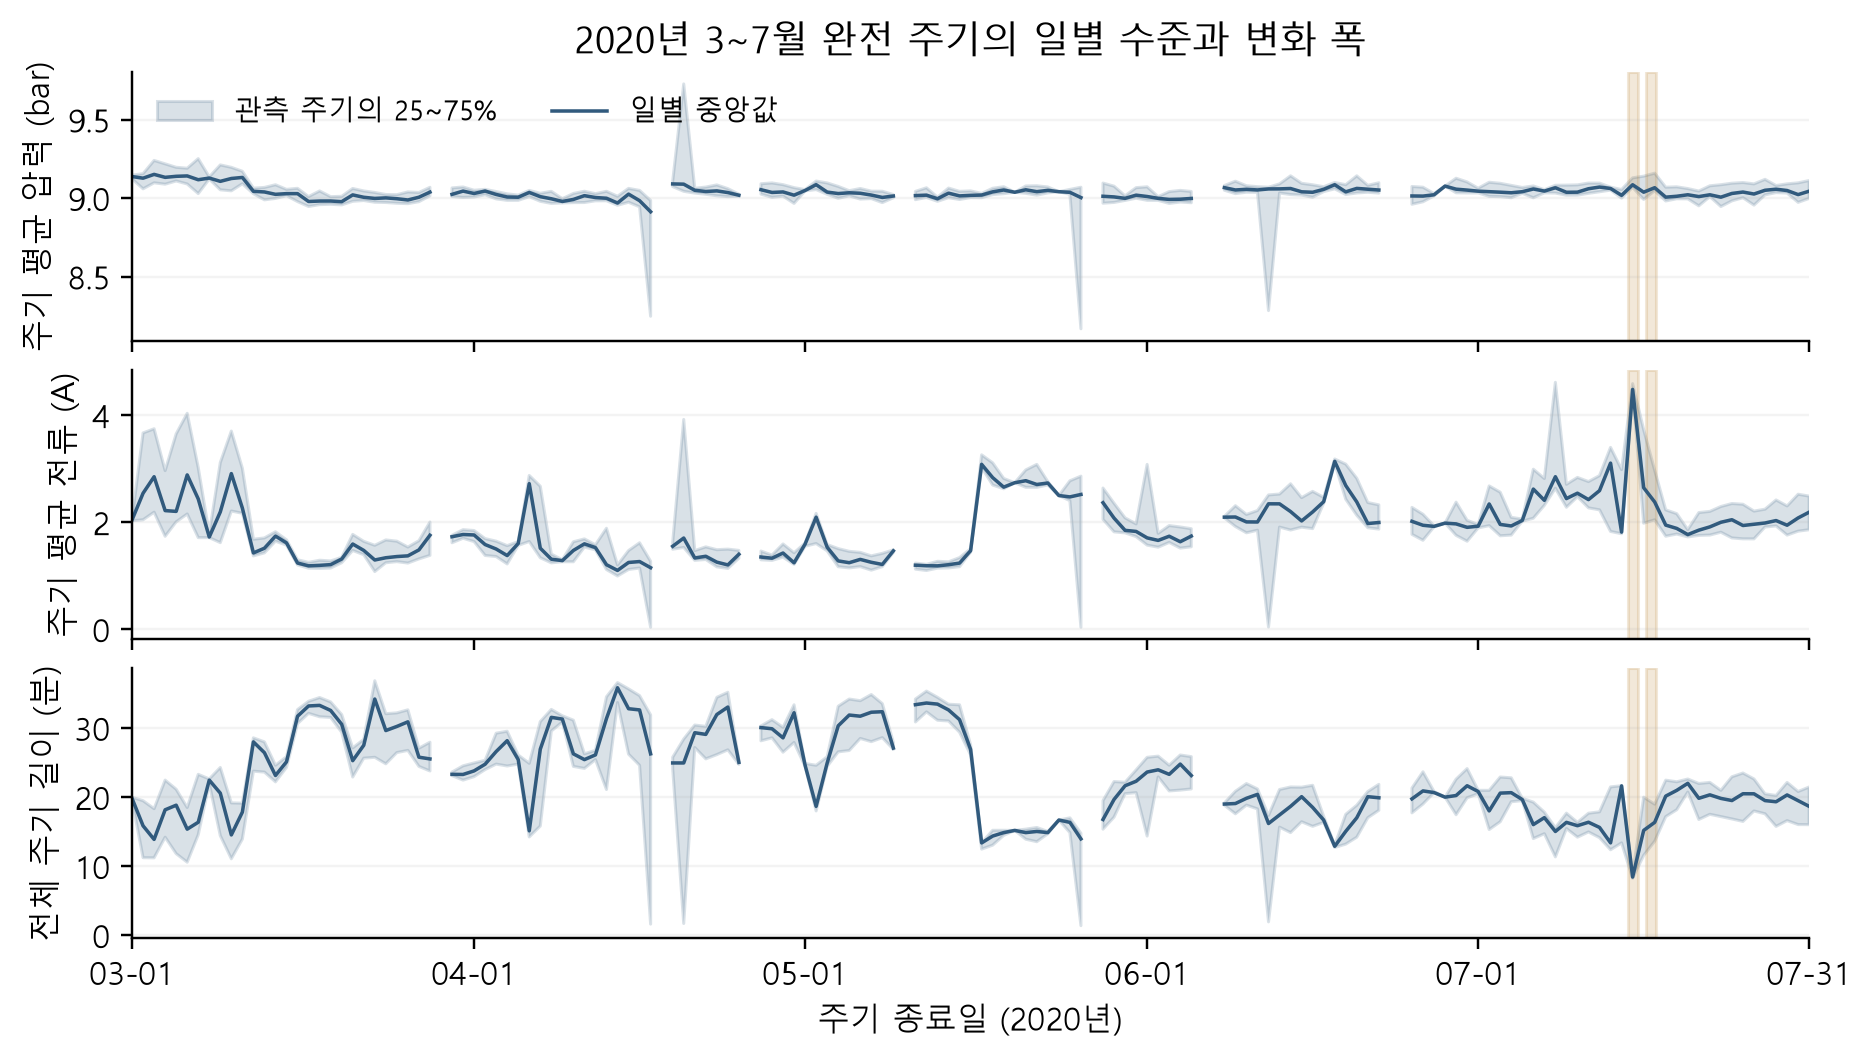

In [4]:
display(Image(filename=str(output_paths()["figure03"])))